<a href="https://colab.research.google.com/github/prabuddhayogi/ai-with-python/blob/feature_scaling/Feature_Scaling_titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(palette="rainbow", style="darkgrid")
import time

%matplotlib inline
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
import random

In [25]:
df=pd.read_csv("/content/drive/MyDrive/AI-python/lecture13/titanic_train_data.csv")
df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [26]:
df_after_dropping = df.drop(columns=["SibSp", "Parch", "Ticket", "Fare", "Cabin", "Embarked"])

In [27]:
df_after_dropping.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
dtypes: float64(1), int64(3), object(2)
memory usage: 41.9+ KB


In [28]:
missing_count = df_after_dropping.isna().sum()
print(missing_count)

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
dtype: int64


In [29]:
df_after_dropping["Age"] = df_after_dropping["Age"].fillna(df_after_dropping["Age"].mean())

In [30]:
missing_count_again = df_after_dropping.isna().sum()
print(missing_count_again)

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
dtype: int64


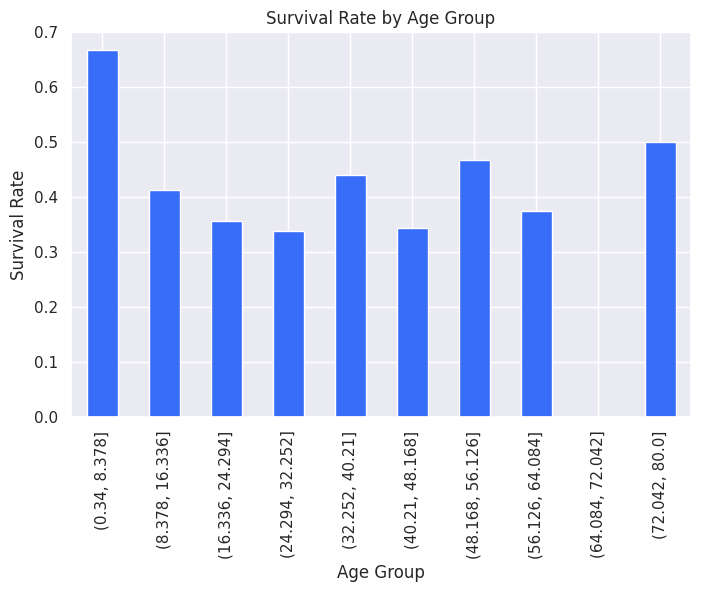

In [31]:
age_bins = pd.cut(df_after_dropping["Age"], bins=10)
survival_by_age = df_after_dropping.groupby(age_bins)["Survived"].mean()
plt.figure(figsize=(8, 5))
survival_by_age.plot(kind="bar")
plt.title("Survival Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Survival Rate")
plt.show()

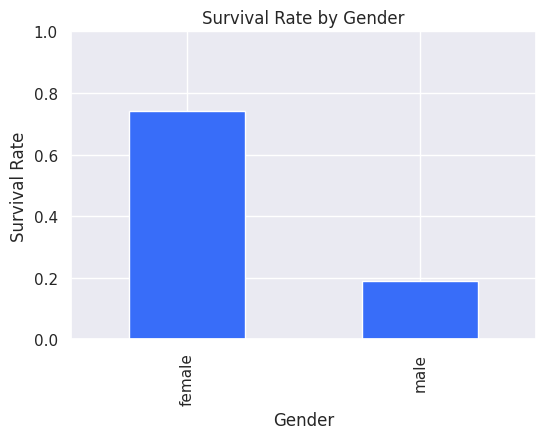

In [32]:
survival_by_gender = df_after_dropping.groupby("Sex")["Survived"].mean()
plt.figure(figsize=(6, 4))
survival_by_gender.plot(kind="bar")
plt.title("Survival Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)
plt.show()

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    df_after_dropping.drop('Survived', axis=1),
    df['Survived'],
    test_size=0.3,
    random_state=42
)

X_train.shape, X_test.shape

((623, 5), (268, 5))

In [36]:
from sklearn.preprocessing import StandardScaler

scaler= StandardScaler()

scaler.fit(X_train)

X_train_scaled=scaler.transform(X_train)
X_test_scaled=scaler.transform(X_test)

ValueError: could not convert string to float: 'Dodge, Master. Washington'

In [35]:
scaler.mean_

AttributeError: 'StandardScaler' object has no attribute 'mean_'

In [37]:
X_train

,PassengerId,Pclass,Name,Sex,Age
445,446,1,"Dodge, Master. Washington",male,4.000000
650,651,3,"Mitkoff, Mr. Mito",male,29.699118
172,173,3,"Johnson, Miss. Eleanor Ileen",female,1.000000
450,451,2,"West, Mr. Edwy Arthur",male,36.000000
314,315,2,"Hart, Mr. Benjamin",male,43.000000
...,...,...,...,...,...
106,107,3,"Salkjelsvik, Miss. Anna Kristine",female,21.000000
270,271,1,"Cairns, Mr. Alexander",male,29.699118
860,861,3,"Hansen, Mr. Claus Peter",male,41.000000
435,436,1,"Carter, Miss. Lucile Polk",female,14.000000


In [38]:
X_train_scaled

NameError: name 'X_train_scaled' is not defined

In [39]:
X_train_scaled=pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled=pd.DataFrame(X_test_scaled, columns=X_test.columns)

NameError: name 'X_train_scaled' is not defined

In [40]:
X_train_scaled

NameError: name 'X_train_scaled' is not defined

In [41]:
np.round(X_train.describe(),1)

,PassengerId,Pclass,Age
count,623.0,623.0,623.0
mean,446.6,2.3,29.3
std,260.0,0.8,13.0
min,1.0,1.0,0.4
25%,216.0,2.0,22.0
50%,454.0,3.0,29.7
75%,675.5,3.0,35.0
max,891.0,3.0,80.0


In [42]:
np.round(X_train_scaled.describe(),1)

NameError: name 'X_train_scaled' is not defined

In [43]:
print("Before Scaling - Mean Age:", X_train['Age'].mean(), "Std Dev:", X_train['Age'].std())
print("After Scaling - Mean Age:", X_train_scaled['Age'].mean(), "Std Dev:", X_train_scaled['Age'].std())


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))


ax1.hist(X_train['Age'], bins=20, color='blue', alpha=0.7)
ax1.set_title('Before Scaling: Age Distribution')
ax1.set_xlabel('Age')
ax1.set_ylabel('Frequency')
ax1.grid(True)

ax2.hist(X_train_scaled['Age'], bins=20, color='red', alpha=0.7)
ax2.set_title('After Scaling: Age Distribution')
ax2.set_xlabel('Scaled Age')
ax2.set_ylabel('Frequency')
ax2.grid(True)

plt.tight_layout()
plt.show()

Before Scaling - Mean Age: 29.34447927485601 Std Dev: 13.02801256088537


NameError: name 'X_train_scaled' is not defined